## Existing Fixed Canaries (Baseline)

The FFF framework selects a seed image from a finite pool (e.g., zebra, elephant, checkerboard) and optimizes its pixels via backpropagation through a frozen YOLOv8 detector. Below are the **seed canary images** from `InitImages/`. These are the starting points — and the finite set an adaptive attacker can enumerate and defeat.

In [ ]:
import os
import cv2
import matplotlib.pyplot as plt

# Path to seed canary images
init_root = '../InitImages'

# Collect all image files (skip subdirectories)
img_files = sorted([
    f for f in os.listdir(init_root)
    if f.lower().endswith(('.jpg', '.jpeg', '.png')) and os.path.isfile(os.path.join(init_root, f))
])

n = len(img_files)
cols = min(n, 5)
rows = (n + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(3 * cols, 3 * rows))
if rows == 1:
    axes = [axes] if n == 1 else list(axes)
else:
    axes = list(axes.flat)

for i, fname in enumerate(img_files):
    img = cv2.imread(os.path.join(init_root, fname))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    axes[i].imshow(img)
    name = os.path.splitext(fname)[0]
    axes[i].set_title(name, fontsize=10)
    axes[i].axis('off')

for j in range(n, len(axes)):
    axes[j].axis('off')

fig.suptitle(f'Fixed Canary Seed Images (K={n}) — The finite pool an attacker can enumerate', fontsize=13)
plt.tight_layout()
plt.show()

## Training a Fixed Canary (Class 17 — Horse)

Below we train a **fixed canary** using the existing FFF pipeline as a baseline. The canary is initialized from `InitImages/17.jpg` (horse) and optimized for 50 epochs with:
- Loss: $\mathcal{L} = 2.0 \cdot \mathcal{L}_{benign} - \mathcal{L}_{adv}$
- Optimizer: Adam, lr=1e-3, batch size=5
- Detector: Frozen YOLOv8n

After training, we evaluate on the 3 test images in `hady_test_samples/`:
- `sample.jpg` — benign (no attack) → expect **no attack detected**
- `sample_adv.jpg` — single person with adversarial patch → expect **attack detected**
- `sample2.jpg` — multiple people with adversarial patches → expect **attack detected**

In [ ]:
import sys
import os
import cv2
import torch
import numpy as np
import random
import matplotlib.pyplot as plt
from types import SimpleNamespace

# Add parent directory to path so we can import from the FFF codebase
sys.path.insert(0, os.path.abspath('..'))

from YOLOv8_Combiner import Canary, freeze_seed
from ObjectDetector.fjn_yolov8 import FJN_YOLOv8 as YOLOv8

# ---- Configuration ----
retrain_from_scratch = False  # True = retrain even if canary already exists

cfg = SimpleNamespace(
    canary_cls_id=17,
    canary_size=80,
    canary_init=True,
    canary_init_path='../InitImages/',
    weight=2.0,
    epoch=50,
    learing_rate=1e-3,
    epoch_save=10,
    batch_size=5,
    benign_root='../Data/traineval/VOC07_YOLOv8/train_120/benign',
    benign_label_root='../Data/traineval/VOC07_YOLOv8/train_120/benign_label',
    adversarial_root='../Data/traineval/VOC07_YOLOv8/train_120/adversarial',
    data_name='VOC07_120',
    img_size=640,
    person_conf=0.05,
    overlap_thresh=0.4,
    defensive_patch_location='cc',
    eval_no_overlap=True,
    margin_size=0,
    faster=False,
    num_works=0,
    seed=301,
    detect_name='yolov8',
    attack_name='fool',
)

save_dir = './canary_cls17_training'
final_canary_path = os.path.join(save_dir, f'canary_{str(cfg.epoch).zfill(3)}.png')

# ---- Skip training if already done ----
if os.path.exists(final_canary_path) and not retrain_from_scratch:
    print(f"Found trained canary at {final_canary_path} — skipping training.")
    print("Set retrain_from_scratch = True to force retrain.\n")
else:
    if retrain_from_scratch and os.path.exists(save_dir):
        import shutil
        shutil.rmtree(save_dir)
        print(f"Cleared {save_dir}/")

    freeze_seed(cfg.seed)
    print("Loading YOLOv8 detector...")
    detector = YOLOv8()

    canary = Canary(cfg, detector)
    canary.init_dataloader()
    canary.init_canary()

    canary.canary_save_path = save_dir
    os.makedirs(save_dir, exist_ok=True)
    canary.save_canary(0)

    print(f"Training for {cfg.epoch} epochs, batch_size={cfg.batch_size}, lr={cfg.learing_rate}, weight={cfg.weight}")
    canary.train()
    print("Training complete!")
    detector.model.eval()

# ---- Show initial vs final canary ----
fig, axes = plt.subplots(1, 2, figsize=(6, 3))
init_img = cv2.imread(os.path.join(save_dir, 'canary_000.png'))
init_img = cv2.cvtColor(init_img, cv2.COLOR_BGR2RGB)
axes[0].imshow(init_img)
axes[0].set_title('Epoch 0 (Init)')
axes[0].axis('off')

final_img = cv2.imread(final_canary_path)
final_img = cv2.cvtColor(final_img, cv2.COLOR_BGR2RGB)
axes[1].imshow(final_img)
axes[1].set_title(f'Epoch {cfg.epoch} (Final)')
axes[1].axis('off')

fig.suptitle(f'Fixed Canary Training (Class {cfg.canary_cls_id})', fontsize=13)
plt.tight_layout()
plt.show()

# ---- Evaluate on hady_test_samples ----
print("\n--- Evaluation on hady_test_samples ---")
if 'detector' not in dir() or 'detector' not in locals():
    detector = YOLOv8()
detector.model.eval()

canary_eval = Canary(cfg, detector)
canary_eval.eval_load_canary(canary_path=final_canary_path, canary_cls_id=cfg.canary_cls_id)

test_dir = '../hady_test_samples'
test_images = sorted(os.listdir(test_dir))

fig, axes = plt.subplots(1, len(test_images), figsize=(5 * len(test_images), 5))
if len(test_images) == 1:
    axes = [axes]

for i, fname in enumerate(test_images):
    img_path = os.path.join(test_dir, fname)
    img_cv = cv2.imread(img_path, 1)
    is_attack = canary_eval.eval_single(img_cv)

    img_rgb = cv2.cvtColor(img_cv, cv2.COLOR_BGR2RGB)
    axes[i].imshow(img_rgb)
    result_text = "ATTACK DETECTED" if is_attack else "No attack"
    color = 'red' if is_attack else 'green'
    axes[i].set_title(f'{fname}\n{result_text}', fontsize=11, color=color)
    axes[i].axis('off')
    print(f"  {fname}: is_attack = {is_attack}")

fig.suptitle('Fixed Canary (Class 17) — Evaluation Results', fontsize=14)
plt.tight_layout()
plt.show()

# Generative Canary Defense for Object Detectors

## Motivation

The original **Fight Fire with Fire (FFF)** framework defends object detectors against adversarial patch attacks by inserting fixed "canary" patches (e.g., a zebra image) near suppressed bounding boxes. If the detector fails to see the canary, an adversarial attack is detected.

**Problem:** A fixed pool of K canaries is vulnerable to adaptive attackers who can optimize a single adversarial patch to suppress all K canaries simultaneously.

**Our extension:** Replace the fixed canary with a lightweight **generator network** $G_\theta(z, b)$ that produces a **unique** 80x80x3 canary patch for every image at inference time. The attacker can never predict which canary will appear.

## Generator Architecture (~200K parameters)

**Input:** $z = [\eta \| b] \in \mathbb{R}^{36}$ where:
- $\eta \sim \mathcal{N}(0, I_{32})$ — 32-dim random noise
- $b = (x_1, y_1, x_2, y_2)_{\text{normalized}}$ — bounding box coordinates

**Layers:**
1. FC: 36 → 256, ReLU
2. FC: 256 → 512, ReLU
3. FC: 512 → 1024, ReLU
4. Reshape to 16 x 8 x 8
5. ConvTranspose2d: 16 → 8, kernel 4, stride 2, pad 1 → 8 x 16 x 16
6. ConvTranspose2d: 8 → 3, kernel 4, stride 2, pad 1 → 3 x 32 x 32
7. Sigmoid activation → pixels in [0, 1]
8. Bilinear interpolation → final 80 x 80 patch

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt


class GenerativeCanary(nn.Module):
    """Lightweight generator that produces unique 80x80x3 canary patches.

    Input:  z = [eta || b] in R^(z_dim + 4)
            eta ~ N(0, I)  (random noise, default 128-dim)
            b = (x1, y1, x2, y2)  (normalized bbox coords)
    Output: canary patch of shape (3, 80, 80) with pixels in [0, 1]
    """

    def __init__(self, z_dim=128, bbox_dim=4, canary_size=80):
        super().__init__()
        self.z_dim = z_dim
        self.bbox_dim = bbox_dim
        self.canary_size = canary_size
        input_dim = z_dim + bbox_dim  # 132

        # Fully connected layers with dropout for diversity
        self.fc = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(256, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(512, 1024),
            nn.ReLU(inplace=True),
        )

        # Transposed convolution layers
        self.deconv = nn.Sequential(
            nn.ConvTranspose2d(16, 8, kernel_size=4, stride=2, padding=1),  # 8x8 -> 16x16
            nn.ReLU(inplace=True),
            nn.ConvTranspose2d(8, 3, kernel_size=4, stride=2, padding=1),   # 16x16 -> 32x32
            nn.Sigmoid(),
        )

    def forward(self, z):
        """Generate canary patch(es).

        Args:
            z: (batch, z_dim+4) concatenated [noise | bbox_coords]
        Returns:
            canary: (batch, 3, 80, 80) pixel values in [0, 1]
        """
        x = self.fc(z)                # (batch, 1024)
        x = x.view(-1, 16, 8, 8)     # (batch, 16, 8, 8)
        x = self.deconv(x)            # (batch, 3, 32, 32)
        # Bilinear interpolation to target size
        x = F.interpolate(x, size=(self.canary_size, self.canary_size), mode='bilinear', align_corners=False)
        return x


# --- Generate and display a sample canary ---
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

generator = GenerativeCanary().to(device)
num_params = sum(p.numel() for p in generator.parameters())
print(f'Generator parameters: {num_params:,} (z_dim=128, dropout=0.3)')

# Sample random noise + fake bbox coords
eta = torch.randn(1, 128, device=device)
bbox = torch.tensor([[0.3, 0.4, 0.5, 0.8]], device=device)
z = torch.cat([eta, bbox], dim=1)  # (1, 132)

with torch.no_grad():
    canary = generator(z)  # (1, 3, 80, 80)

# Display
canary_img = canary[0].cpu().permute(1, 2, 0).numpy()  # (80, 80, 3)
plt.figure(figsize=(3, 3))
plt.imshow(canary_img)
plt.title(f'Sample Canary (80x80) - {num_params:,} params')
plt.axis('off')
plt.tight_layout()
plt.show()

## On-the-Fly Canary: Generate → Train → Evaluate

This cell connects the generative canary to the existing FFF training pipeline:

1. **Generate**: The `GenerativeCanary` network produces a random 80x80 canary from a sampled $z = [\eta \| b]$
2. **Save**: The generated image is saved to `on_the_fly_canary/` as the seed init image
3. **Train**: The FFF pipeline picks it up and optimizes its pixels for 50 epochs (same as the fixed canary baseline)
4. **Evaluate**: The trained canary is tested on `hady_test_samples/`

Set `retrain_from_scratch = True` to wipe the folder and regenerate + retrain everything from scratch.

In [ ]:
import sys, os, shutil, cv2, torch, numpy as np, random
import matplotlib.pyplot as plt
from types import SimpleNamespace

sys.path.insert(0, os.path.abspath('..'))
from YOLOv8_Combiner import Canary, freeze_seed
from ObjectDetector.fjn_yolov8 import FJN_YOLOv8 as YOLOv8

# =============================================
#  FLAGS
# =============================================
retrain_from_scratch = False  # True = wipe on_the_fly_canary/ and redo everything
canary_cls_id = 22            # COCO class the detector will look for

# =============================================
#  PATHS
# =============================================
work_dir = './on_the_fly_canary'
init_dir = os.path.join(work_dir, 'init')
train_dir = os.path.join(work_dir, 'training')
final_canary_name = 'canary_050.png'
final_canary_path = os.path.join(train_dir, final_canary_name)

# =============================================
#  STEP 0: Clean slate if retrain_from_scratch
# =============================================
if retrain_from_scratch and os.path.exists(work_dir):
    shutil.rmtree(work_dir)
    print(f"Cleared {work_dir}/")

os.makedirs(init_dir, exist_ok=True)
os.makedirs(train_dir, exist_ok=True)

# =============================================
#  STEP 1 & 2: Generate + Train (skip if already done)
# =============================================
already_trained = os.path.exists(final_canary_path)

if already_trained and not retrain_from_scratch:
    print(f"Found trained canary at {final_canary_path} — skipping generation & training.")
    print("Set retrain_from_scratch = True to redo everything.\n")
else:
    # --- Step 1: Generate seed ---
    print("=== Step 1: Generating seed canary with GenerativeCanary ===")
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    generator = GenerativeCanary().to(device)

    eta = torch.randn(1, 32, device=device)
    bbox = torch.tensor([[0.3, 0.4, 0.5, 0.8]], device=device)
    z = torch.cat([eta, bbox], dim=1)

    with torch.no_grad():
        canary_tensor = generator(z)

    canary_np = (canary_tensor[0].cpu().permute(1, 2, 0).numpy() * 255).astype(np.uint8)
    canary_bgr = cv2.cvtColor(canary_np, cv2.COLOR_RGB2BGR)
    seed_path = os.path.join(init_dir, f'{canary_cls_id}.jpg')
    cv2.imwrite(seed_path, canary_bgr)
    print(f"  Saved generated seed to {seed_path}")

    plt.figure(figsize=(2.5, 2.5))
    plt.imshow(canary_np)
    plt.title('Generated Seed Canary')
    plt.axis('off')
    plt.tight_layout()
    plt.show()

    # --- Step 2: Train ---
    print("\n=== Step 2: Training with FFF pipeline (50 epochs) ===")
    freeze_seed(301)

    cfg = SimpleNamespace(
        canary_cls_id=canary_cls_id, canary_size=80, canary_init=True,
        canary_init_path=init_dir, weight=2.0, epoch=50, learing_rate=1e-3,
        epoch_save=10, batch_size=5,
        benign_root='../Data/traineval/VOC07_YOLOv8/train_120/benign',
        benign_label_root='../Data/traineval/VOC07_YOLOv8/train_120/benign_label',
        adversarial_root='../Data/traineval/VOC07_YOLOv8/train_120/adversarial',
        data_name='VOC07_120', img_size=640, person_conf=0.05, overlap_thresh=0.4,
        defensive_patch_location='cc', eval_no_overlap=True, margin_size=0,
        faster=False, num_works=0, seed=301, detect_name='yolov8', attack_name='fool',
    )

    detector = YOLOv8()
    canary = Canary(cfg, detector)
    canary.init_dataloader()
    canary.init_canary()
    canary.canary_save_path = train_dir
    canary.save_canary(0)
    canary.train()
    print("Training complete!")
    detector.model.eval()

# =============================================
#  STEP 3: Show seed vs trained result
# =============================================
print("\n=== Step 3: Seed vs Trained Canary ===")
fig, axes = plt.subplots(1, 2, figsize=(6, 3))

seed_img = cv2.imread(os.path.join(train_dir, 'canary_000.png'))
seed_img = cv2.cvtColor(seed_img, cv2.COLOR_BGR2RGB)
axes[0].imshow(seed_img)
axes[0].set_title('Epoch 0 (Generated Seed)')
axes[0].axis('off')

final_img = cv2.imread(final_canary_path)
final_img = cv2.cvtColor(final_img, cv2.COLOR_BGR2RGB)
axes[1].imshow(final_img)
axes[1].set_title('Epoch 50 (Trained)')
axes[1].axis('off')

fig.suptitle('On-the-Fly Canary: Generated Seed -> FFF Training', fontsize=13)
plt.tight_layout()
plt.show()

# =============================================
#  STEP 4: Evaluate on hady_test_samples
# =============================================
print("\n=== Step 4: Evaluation on hady_test_samples ===")

# Load detector fresh if we skipped training (no detector in scope)
try:
    detector.model.eval()
except NameError:
    detector = YOLOv8()
    detector.model.eval()

eval_cfg = SimpleNamespace(
    canary_cls_id=canary_cls_id, canary_size=80, img_size=640,
    person_conf=0.05, overlap_thresh=0.4, defensive_patch_location='cc',
    eval_no_overlap=True, margin_size=0, faster=False,
)

canary_eval = Canary(eval_cfg, detector)
canary_eval.eval_load_canary(canary_path=final_canary_path, canary_cls_id=canary_cls_id)

test_dir = '../hady_test_samples'
test_images = sorted(os.listdir(test_dir))

fig, axes = plt.subplots(1, len(test_images), figsize=(5 * len(test_images), 5))
if len(test_images) == 1:
    axes = [axes]

for i, fname in enumerate(test_images):
    img_path = os.path.join(test_dir, fname)
    img_cv = cv2.imread(img_path, 1)
    is_attack = canary_eval.eval_single(img_cv)

    img_rgb = cv2.cvtColor(img_cv, cv2.COLOR_BGR2RGB)
    axes[i].imshow(img_rgb)
    result_text = "ATTACK DETECTED" if is_attack else "No attack"
    color = 'red' if is_attack else 'green'
    axes[i].set_title(f'{fname}\n{result_text}', fontsize=11, color=color)
    axes[i].axis('off')
    print(f"  {fname}: is_attack = {is_attack}")

fig.suptitle('On-the-Fly Canary — Evaluation Results', fontsize=14)
plt.tight_layout()
plt.show()

## Full VOC07 Evaluation: Fixed Canary vs On-the-Fly Canary

We evaluate both trained canaries on the full VOC07 test set across all 4 attack types:
- **AdvPatch** (376 adv + 376 benign images)
- **UPC** (73 + 73)
- **TCEGA** (95 + 95)
- **Natural** (205 + 205)

For each image we run `eval_single()` and classify:
- Adversarial image: `is_attack=True` → TP, `False` → FN
- Benign image: `is_attack=True` → FP, `False` → TN

Metrics: **F1** = 2PR/(P+R), **FPR** = FP/(FP+TN)

Results are compared against the paper baseline and our Level B reproduction.

In [ ]:
import sys, os, cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from types import SimpleNamespace
from tqdm import tqdm
from IPython.display import display, HTML

sys.path.insert(0, os.path.abspath('..'))
from YOLOv8_Combiner import Canary
from ObjectDetector.fjn_yolov8 import FJN_YOLOv8 as YOLOv8

# =============================================
#  Reusable evaluation function
# =============================================
def evaluate_canary_full(canary_obj, test_root, attacks):
    results = {}
    for attack in attacks:
        adv_dir = os.path.join(test_root, attack, 'adversarial')
        ben_dir = os.path.join(test_root, attack, 'benign')
        TP, FP, FN, TN = 0, 0, 0, 0

        adv_files = sorted([f for f in os.listdir(adv_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
        for fname in tqdm(adv_files, desc=f'{attack} adv', leave=False):
            img = cv2.imread(os.path.join(adv_dir, fname), 1)
            if canary_obj.eval_single(img): TP += 1
            else: FN += 1

        ben_files = sorted([f for f in os.listdir(ben_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
        for fname in tqdm(ben_files, desc=f'{attack} ben', leave=False):
            img = cv2.imread(os.path.join(ben_dir, fname), 1)
            if canary_obj.eval_single(img): FP += 1
            else: TN += 1

        P = TP / (TP + FP) if (TP + FP) > 0 else 0
        R = TP / (TP + FN) if (TP + FN) > 0 else 0
        F1 = 2 * P * R / (P + R) if (P + R) > 0 else 0
        FPR = FP / (FP + TN) if (FP + TN) > 0 else 0
        results[attack] = {'TP': TP, 'FP': FP, 'FN': FN, 'TN': TN,
                           'Precision': P, 'Recall': R, 'F1': F1, 'FPR': FPR}
        print(f"  {attack:10s}  F1={F1:.3f}  FPR={FPR:.3f}  (TP={TP} FP={FP} FN={FN} TN={TN})")
    return results


def styled_comparison_table(all_results, paper_baseline):
    """Build and display a styled HTML comparison table."""
    attacks = list(paper_baseline.keys())

    # Build dataframe
    rows = []
    for attack in attacks:
        row = {'Attack': attack, 'Paper F1': paper_baseline[attack]}
        for name, results in all_results.items():
            r = results[attack]
            row[f'{name} F1'] = r['F1']
            row[f'{name} FPR'] = r['FPR']
        # Delta: on-the-fly vs paper
        otf_key = [k for k in all_results.keys() if 'Fly' in k][0]
        delta = all_results[otf_key][attack]['F1'] - paper_baseline[attack]
        row['Delta'] = delta
        rows.append(row)

    df = pd.DataFrame(rows).set_index('Attack')

    # Style function
    def color_f1(val):
        if isinstance(val, float) and val >= 0.90:
            return 'background-color: #c6efce; color: #006100; font-weight: bold'
        elif isinstance(val, float) and val >= 0.85:
            return 'background-color: #ffeb9c; color: #9c5700'
        return ''

    def color_fpr(val):
        if isinstance(val, float) and val <= 0.05:
            return 'background-color: #c6efce; color: #006100; font-weight: bold'
        elif isinstance(val, float) and val <= 0.10:
            return 'background-color: #ffeb9c; color: #9c5700'
        return ''

    def color_delta(val):
        if isinstance(val, float) and val > 0:
            return 'background-color: #c6efce; color: #006100; font-weight: bold'
        elif isinstance(val, float) and val < 0:
            return 'background-color: #ffc7ce; color: #9c0006; font-weight: bold'
        return ''

    # Format
    fmt = {'Paper F1': '{:.3f}'}
    for name in all_results.keys():
        fmt[f'{name} F1'] = '{:.3f}'
        fmt[f'{name} FPR'] = '{:.3f}'
    fmt['Delta'] = '{:+.3f}'

    styled = (df.style
              .format(fmt)
              .applymap(color_f1, subset=[c for c in df.columns if 'F1' in c and 'Delta' not in c])
              .applymap(color_fpr, subset=[c for c in df.columns if 'FPR' in c])
              .applymap(color_delta, subset=['Delta'])
              .set_caption('Mode #1 (Canary) — Three-Way Comparison on YOLOv8 / VOC07')
              .set_table_styles([
                  {'selector': 'caption', 'props': [('font-size', '16px'), ('font-weight', 'bold'), ('margin-bottom', '10px')]},
                  {'selector': 'th', 'props': [('background-color', '#2c3e50'), ('color', 'white'), ('padding', '8px 12px'), ('text-align', 'center')]},
                  {'selector': 'td', 'props': [('padding', '6px 12px'), ('text-align', 'center')]},
                  {'selector': 'tr:nth-child(even)', 'props': [('background-color', '#f8f9fa')]},
                  {'selector': 'table', 'props': [('border-collapse', 'collapse'), ('margin', '10px 0'), ('font-family', 'Segoe UI, Arial, sans-serif')]},
                  {'selector': 'th, td', 'props': [('border', '1px solid #dee2e6')]},
              ]))

    display(styled)
    return df


# =============================================
#  Configuration
# =============================================
test_root = '../Data/testeval/VOC07_YOLOv8/test'
attacks = ['AdvPatch', 'UPC', 'TCEGA', 'Natural']
paper_baseline = {'AdvPatch': 0.974, 'UPC': 0.936, 'TCEGA': 0.807, 'Natural': 0.871}

fixed_canary_path = './canary_cls17_training/canary_050.png'
otf_canary_path = './on_the_fly_canary/training/canary_050.png'

# =============================================
#  Load detector once
# =============================================
print("Loading YOLOv8 detector...")
detector = YOLOv8()
detector.model.eval()

eval_cfg_17 = SimpleNamespace(
    canary_cls_id=17, canary_size=80, img_size=640,
    person_conf=0.05, overlap_thresh=0.4, defensive_patch_location='cc',
    eval_no_overlap=True, margin_size=0, faster=False,
)
eval_cfg_22 = SimpleNamespace(
    canary_cls_id=22, canary_size=80, img_size=640,
    person_conf=0.05, overlap_thresh=0.4, defensive_patch_location='cc',
    eval_no_overlap=True, margin_size=0, faster=False,
)

all_results = {}

# =============================================
#  Evaluate Fixed Canary (Class 17)
# =============================================
print("\n========== Fixed Canary (Class 17 - Horse) ==========")
canary_fixed = Canary(eval_cfg_17, detector)
canary_fixed.eval_load_canary(canary_path=fixed_canary_path, canary_cls_id=17)
all_results['Fixed (cls17)'] = evaluate_canary_full(canary_fixed, test_root, attacks)

# =============================================
#  Evaluate On-the-Fly Canary (Class 22)
# =============================================
print("\n========== On-the-Fly Canary (Generated + Trained) ==========")
canary_otf = Canary(eval_cfg_22, detector)
canary_otf.eval_load_canary(canary_path=otf_canary_path, canary_cls_id=22)
all_results['On-the-Fly'] = evaluate_canary_full(canary_otf, test_root, attacks)

# =============================================
#  Display styled comparison table
# =============================================
print()
df = styled_comparison_table(all_results, paper_baseline)

## Extension 1: True Generative Canary Training

This is the **real contribution**. Instead of optimizing a fixed image's pixels, we train the **generator weights** directly through the frozen YOLOv8 detector.

**Training (each batch):**
1. Sample fresh z with random noise + bbox
2. Generator produces canary: c = G(z) -- shape (3, 80, 80)
3. Paste c into benign + adversarial images (same placement as FFF)
4. Compute loss through frozen YOLOv8: L = 2.0 * L_benign - L_adv
5. loss.backward() flows: YOLOv8 --> pasted canary pixels --> generator weights
6. optimizer.step() updates the generator (not pixels, not YOLOv8)

**After training:** The generator IS the defense. Sample any z, get a unique trained canary instantly. Infinite canaries from ~200K parameters.

**At evaluation:** Each test image gets a **fresh, unique canary** -- the attacker can never predict which one.

In [8]:
import sys, os, shutil, glob, copy, cv2, torch, random
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from types import SimpleNamespace
from copy import deepcopy
from tqdm import tqdm
from torchvision import transforms

sys.path.insert(0, os.path.abspath('..'))
from YOLOv8_Combiner import (
    add_defensivepatch_into_tensor, make_yolo_train_label,
    Yolov8Dataset, Canary, freeze_seed
)
from ObjectDetector.fjn_yolov8 import FJN_YOLOv8 as YOLOv8

# =============================================
#  FLAGS
# =============================================
retrain_from_scratch = True
canary_cls_id = 22
EPOCHS = 50
BATCH_SIZE = 5
LR = 1e-3
WEIGHT = 2.0            # lambda_c
SAVE_EVERY = 10
DIVERSITY_WEIGHT = 0.5  # increased from 0.1
Z_DIM = 128             # increased from 32

# =============================================
#  PATHS
# =============================================
work_dir = './generative_canary_training'
ckpt_dir = os.path.join(work_dir, 'checkpoints')
final_ckpt = os.path.join(ckpt_dir, f'generator_epoch_{EPOCHS:03d}.pt')

# =============================================
#  STEP 0: Clean slate or resume
# =============================================
if retrain_from_scratch and os.path.exists(work_dir):
    shutil.rmtree(work_dir)
    print(f"Cleared {work_dir}/")

os.makedirs(ckpt_dir, exist_ok=True)

# =============================================
#  Check if training is already done
# =============================================
if os.path.exists(final_ckpt) and not retrain_from_scratch:
    print(f"Found final checkpoint at {final_ckpt} -- skipping training.")
    print("Set retrain_from_scratch = True to force retrain.\n")

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    generator = GenerativeCanary(z_dim=Z_DIM).to(device)
    ckpt = torch.load(final_ckpt, map_location=device)
    generator.load_state_dict(ckpt['generator_state_dict'])
    generator.eval()
    print(f"Loaded trained generator (epoch {ckpt['epoch']})")

else:
    # ==============================================
    #  STEP 1: Setup
    # ==============================================
    print("=== True Generative Canary Training ===")
    print(f"z_dim={Z_DIM}, dropout=0.3, diversity_weight={DIVERSITY_WEIGHT}")
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Device: {device}")

    freeze_seed(301)

    cfg = SimpleNamespace(
        canary_cls_id=canary_cls_id, canary_size=80,
        img_size=640, person_conf=0.05, overlap_thresh=0.4,
        defensive_patch_location='cc', eval_no_overlap=True,
        margin_size=0, faster=False,
    )

    # Detector (frozen)
    print("Loading YOLOv8 detector...")
    detector = YOLOv8()
    for p in detector.model.parameters():
        p.requires_grad = False

    # Generator with increased z_dim
    generator = GenerativeCanary(z_dim=Z_DIM).to(device)
    print(f"Generator parameters: {sum(p.numel() for p in generator.parameters()):,}")

    # Optimizer & scheduler on generator weights only
    optimizer = optim.Adam(generator.parameters(), lr=LR, amsgrad=True)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

    # Dataloader
    train_dataset = Yolov8Dataset(
        '../Data/traineval/VOC07_YOLOv8/train_120/benign',
        '../Data/traineval/VOC07_YOLOv8/train_120/adversarial',
        '../Data/traineval/VOC07_YOLOv8/train_120/benign_label',
        cfg.img_size
    )
    train_loader = torch.utils.data.DataLoader(
        train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0, drop_last=True
    )

    # ==============================================
    #  STEP 2: Resume from checkpoint if available
    # ==============================================
    start_epoch = 1
    existing_ckpts = sorted(glob.glob(os.path.join(ckpt_dir, 'generator_epoch_*.pt')))
    if existing_ckpts and not retrain_from_scratch:
        latest_ckpt = existing_ckpts[-1]
        ckpt = torch.load(latest_ckpt, map_location=device)
        generator.load_state_dict(ckpt['generator_state_dict'])
        optimizer.load_state_dict(ckpt['optimizer_state_dict'])
        scheduler.load_state_dict(ckpt['scheduler_state_dict'])
        start_epoch = ckpt['epoch'] + 1
        print(f"Resumed from {latest_ckpt} (epoch {ckpt['epoch']})")

    # ==============================================
    #  STEP 3: Training loop
    # ==============================================
    print(f"\nTraining epochs {start_epoch} to {EPOCHS}, batch_size={BATCH_SIZE}, lr={LR}, weight={WEIGHT}")

    t = tqdm(total=EPOCHS - start_epoch + 1, ascii=True)
    for epoch in range(start_epoch, EPOCHS + 1):
        t.set_description(f'gen_canary epoch: {epoch}/{EPOCHS}')
        generator.train()

        for i_batch, (benign_input, benign_label, adv_input) in enumerate(train_loader):
            benign_input = benign_input.cuda()
            adv_input = adv_input.cuda()
            bs = benign_input.shape[0]

            # Per-image z with random bbox
            eta = torch.randn(bs, Z_DIM, device=device)
            bbox = torch.rand(bs, 4, device=device)
            z = torch.cat([eta, bbox], dim=1)

            # Generate one unique canary per image
            canary_patches = generator(z)  # (bs, 3, 80, 80)

            # Paste per-image canaries
            adv_all_canary_pos = []
            benign_all_canary_pos = []

            detector.model.eval()
            for bi in range(bs):
                canary_bi = canary_patches[bi]
                _, adv_pos = add_defensivepatch_into_tensor(
                    detector, cfg, adv_input[bi:bi+1], canary_bi, random_palce=True
                )
                _, benign_pos = add_defensivepatch_into_tensor(
                    detector, cfg, benign_input[bi:bi+1], canary_bi, random_palce=True
                )
                adv_all_canary_pos.extend(adv_pos)
                benign_all_canary_pos.extend(benign_pos)

            # Build YOLO label batches
            adv_batch = make_yolo_train_label(adv_input, adv_all_canary_pos)
            benign_batch = make_yolo_train_label(benign_input, benign_all_canary_pos)

            # Forward through YOLOv8 in train mode
            detector.model.train()
            adv_loss, adv_items = detector.model.model(adv_batch)
            benign_loss, benign_items = detector.model.model(benign_batch)

            # FFF canary loss
            canary_loss = WEIGHT * benign_loss - adv_loss

            # Diversity loss -- maximize pairwise L2 distance
            canaries_flat = canary_patches.view(bs, -1)
            dists = torch.cdist(canaries_flat, canaries_flat, p=2)
            mask = torch.triu(torch.ones(bs, bs, device=device), diagonal=1).bool()
            diversity_loss = -dists[mask].mean()

            loss = canary_loss + DIVERSITY_WEIGHT * diversity_loss

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            t.set_postfix({
                'b_loss': f'{benign_loss.item():.4f}',
                'a_loss': f'{adv_loss.item():.4f}',
                'div': f'{-diversity_loss.item():.2f}',
            })

        scheduler.step()

        if epoch % SAVE_EVERY == 0 or epoch == EPOCHS:
            ckpt_path = os.path.join(ckpt_dir, f'generator_epoch_{epoch:03d}.pt')
            torch.save({
                'epoch': epoch,
                'generator_state_dict': generator.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'scheduler_state_dict': scheduler.state_dict(),
            }, ckpt_path)
            tqdm.write(f"  Saved checkpoint: {ckpt_path}")

        t.update(1)

    t.close()
    print("Training complete!")
    detector.model.eval()
    generator.eval()

# =============================================
#  STEP 4: Show 8 diverse canaries
# =============================================
print("\n=== Trained Generator: 8 Diverse Canaries ===")
generator.eval()
n_show = 8
eta_samples = torch.randn(n_show, Z_DIM, device=device)
bbox_samples = torch.rand(n_show, 4, device=device)
z_samples = torch.cat([eta_samples, bbox_samples], dim=1)

with torch.no_grad():
    canaries = generator(z_samples)

fig, axes = plt.subplots(2, 4, figsize=(12, 6))
for i, ax in enumerate(axes.flat):
    img = canaries[i].cpu().permute(1, 2, 0).numpy()
    ax.imshow(img)
    ax.set_title(f'Canary #{i+1}')
    ax.axis('off')
fig.suptitle('8 Unique Canaries from Trained Generator G(z)', fontsize=14)
plt.tight_layout()
plt.show()

# Pairwise L2 distance
canaries_flat = canaries.view(n_show, -1)
dists = torch.cdist(canaries_flat, canaries_flat, p=2)
mask = torch.triu(torch.ones(n_show, n_show), diagonal=1).bool()
mean_dist = dists[mask].mean().item()
print(f"Mean pairwise L2 distance: {mean_dist:.2f} (higher = more diverse)")

# =============================================
#  STEP 5: Evaluate on hady_test_samples
# =============================================
print("\n=== Evaluation on hady_test_samples (unique canary per image) ===")

try:
    detector.model.eval()
except NameError:
    detector = YOLOv8()
    detector.model.eval()

eval_cfg = SimpleNamespace(
    canary_cls_id=canary_cls_id, canary_size=80, img_size=640,
    person_conf=0.05, overlap_thresh=0.4, defensive_patch_location='cc',
    eval_no_overlap=True, margin_size=0, faster=False,
)
canary_eval = Canary(eval_cfg, detector)

test_dir = '../hady_test_samples'
test_images = sorted(os.listdir(test_dir))

fig, axes = plt.subplots(1, len(test_images), figsize=(5 * len(test_images), 5))
if len(test_images) == 1:
    axes = [axes]

for i, fname in enumerate(test_images):
    eta = torch.randn(1, Z_DIM, device=device)
    bbox = torch.rand(1, 4, device=device)
    z = torch.cat([eta, bbox], dim=1)
    with torch.no_grad():
        canary_patch = generator(z)

    canary_np = (canary_patch[0].cpu().permute(1, 2, 0).numpy() * 255).astype(np.uint8)
    canary_bgr = cv2.cvtColor(canary_np, cv2.COLOR_RGB2BGR)
    canary_eval.eval_canary = canary_bgr
    canary_eval.canary_cls_id = canary_cls_id

    img_path = os.path.join(test_dir, fname)
    img_cv = cv2.imread(img_path, 1)
    is_attack = canary_eval.eval_single(img_cv)

    img_rgb = cv2.cvtColor(img_cv, cv2.COLOR_BGR2RGB)
    axes[i].imshow(img_rgb)
    result_text = "ATTACK DETECTED" if is_attack else "No attack"
    color = 'red' if is_attack else 'green'
    axes[i].set_title(f'{fname}\n{result_text}', fontsize=11, color=color)
    axes[i].axis('off')
    print(f"  {fname}: is_attack = {is_attack} (unique canary)")

fig.suptitle('True Generative Canary -- Unique Canary Per Image', fontsize=14)
plt.tight_layout()
plt.show()

YOLOv8n summary (fused): 168 layers, 3151904 parameters, 0 gradients, 8.7 GFLOPs


Cleared ./generative_canary_training/
=== True Generative Canary Training ===
z_dim=128, dropout=0.3, diversity_weight=0.5
Device: cuda
Loading YOLOv8 detector...
Generator parameters: 693,387

Training epochs 1 to 50, batch_size=5, lr=0.001, weight=2.0


gen_canary epoch: 5/50:   8%|8         | 4/50 [00:21<03:55,  5.12s/it, b_loss=74.4459, a_loss=87.0123, div=2.57]   

KeyboardInterrupt: 

## Full VOC07 Evaluation: Generative Canary

We run the trained generator on the full VOC07 test set across all 4 attack types.

**Key difference from fixed canary evaluation:** Each test image gets a **fresh, unique canary** generated on the fly. No two images see the same canary.

Results are compared against:
- **Paper baseline** (original FFF, fixed zebra canary)
- **Fixed canary (cls-17)** trained in this notebook
- **On-the-fly canary** (random seed, pixel-optimized)


In [ ]:
import sys, os, cv2, torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from types import SimpleNamespace
from tqdm import tqdm
from copy import deepcopy
from IPython.display import display

sys.path.insert(0, os.path.abspath('..'))
from YOLOv8_Combiner import Canary
from ObjectDetector.fjn_yolov8 import FJN_YOLOv8 as YOLOv8

# =============================================
#  Config
# =============================================
Z_DIM = 128
canary_cls_id = 22
test_root = '../Data/testeval/VOC07_YOLOv8/test'
attacks = ['AdvPatch', 'UPC', 'TCEGA', 'Natural']
paper_baseline = {'AdvPatch': 0.974, 'UPC': 0.936, 'TCEGA': 0.807, 'Natural': 0.871}

gen_ckpt_path = './generative_canary_training/checkpoints/generator_epoch_050.pt'

# =============================================
#  Load generator
# =============================================
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
generator = GenerativeCanary(z_dim=Z_DIM).to(device)
ckpt = torch.load(gen_ckpt_path, map_location=device)
generator.load_state_dict(ckpt['generator_state_dict'])
generator.eval()
print(f"Loaded trained generator (epoch {ckpt['epoch']})")

# =============================================
#  Load detector
# =============================================
print("Loading YOLOv8 detector...")
detector = YOLOv8()
detector.model.eval()

eval_cfg = SimpleNamespace(
    canary_cls_id=canary_cls_id, canary_size=80, img_size=640,
    person_conf=0.05, overlap_thresh=0.4, defensive_patch_location='cc',
    eval_no_overlap=True, margin_size=0, faster=False,
)

# =============================================
#  Evaluate with per-image unique canary
# =============================================
def evaluate_generative_canary(generator, detector, eval_cfg, test_root, attacks, z_dim, device):
    canary_eval = Canary(eval_cfg, detector)
    results = {}

    for attack in attacks:
        adv_dir = os.path.join(test_root, attack, 'adversarial')
        ben_dir = os.path.join(test_root, attack, 'benign')
        TP, FP, FN, TN = 0, 0, 0, 0

        # Adversarial images
        adv_files = sorted([f for f in os.listdir(adv_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
        for fname in tqdm(adv_files, desc=f'{attack} adv', leave=False):
            # Fresh unique canary for this image
            eta = torch.randn(1, z_dim, device=device)
            bbox = torch.rand(1, 4, device=device)
            z = torch.cat([eta, bbox], dim=1)
            with torch.no_grad():
                patch = generator(z)
            canary_np = (patch[0].cpu().permute(1, 2, 0).numpy() * 255).astype(np.uint8)
            canary_eval.eval_canary = cv2.cvtColor(canary_np, cv2.COLOR_RGB2BGR)
            canary_eval.canary_cls_id = eval_cfg.canary_cls_id

            img = cv2.imread(os.path.join(adv_dir, fname), 1)
            if canary_eval.eval_single(img): TP += 1
            else: FN += 1

        # Benign images
        ben_files = sorted([f for f in os.listdir(ben_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
        for fname in tqdm(ben_files, desc=f'{attack} ben', leave=False):
            eta = torch.randn(1, z_dim, device=device)
            bbox = torch.rand(1, 4, device=device)
            z = torch.cat([eta, bbox], dim=1)
            with torch.no_grad():
                patch = generator(z)
            canary_np = (patch[0].cpu().permute(1, 2, 0).numpy() * 255).astype(np.uint8)
            canary_eval.eval_canary = cv2.cvtColor(canary_np, cv2.COLOR_RGB2BGR)
            canary_eval.canary_cls_id = eval_cfg.canary_cls_id

            img = cv2.imread(os.path.join(ben_dir, fname), 1)
            if canary_eval.eval_single(img): FP += 1
            else: TN += 1

        P = TP / (TP + FP) if (TP + FP) > 0 else 0
        R = TP / (TP + FN) if (TP + FN) > 0 else 0
        F1 = 2 * P * R / (P + R) if (P + R) > 0 else 0
        FPR = FP / (FP + TN) if (FP + TN) > 0 else 0
        results[attack] = {'TP': TP, 'FP': FP, 'FN': FN, 'TN': TN,
                           'Precision': P, 'Recall': R, 'F1': F1, 'FPR': FPR}
        print(f"  {attack:10s}  F1={F1:.3f}  FPR={FPR:.3f}  (TP={TP} FP={FP} FN={FN} TN={TN})")

    return results


print("\n========== Generative Canary (unique per image) ==========")
gen_results = evaluate_generative_canary(generator, detector, eval_cfg, test_root, attacks, Z_DIM, device)

# =============================================
#  Build comparison table with all methods
# =============================================
# Load previous results if available from cell-9
# Otherwise just show paper + generative
all_results = {}

# Try to load fixed canary results
fixed_path = './canary_cls17_training/canary_050.png'
if os.path.exists(fixed_path):
    print("\n========== Fixed Canary (Class 17) ==========")
    eval_cfg_17 = SimpleNamespace(
        canary_cls_id=17, canary_size=80, img_size=640,
        person_conf=0.05, overlap_thresh=0.4, defensive_patch_location='cc',
        eval_no_overlap=True, margin_size=0, faster=False,
    )
    canary_fixed = Canary(eval_cfg_17, detector)
    canary_fixed.eval_load_canary(canary_path=fixed_path, canary_cls_id=17)
    from YOLOv8_Combiner import Canary as CanaryClass
    fixed_results = {}
    for attack in attacks:
        adv_dir = os.path.join(test_root, attack, 'adversarial')
        ben_dir = os.path.join(test_root, attack, 'benign')
        TP, FP, FN, TN = 0, 0, 0, 0
        for fname in tqdm(sorted(os.listdir(adv_dir)), desc=f'{attack} adv', leave=False):
            if not fname.lower().endswith(('.jpg','.jpeg','.png')): continue
            img = cv2.imread(os.path.join(adv_dir, fname), 1)
            if canary_fixed.eval_single(img): TP += 1
            else: FN += 1
        for fname in tqdm(sorted(os.listdir(ben_dir)), desc=f'{attack} ben', leave=False):
            if not fname.lower().endswith(('.jpg','.jpeg','.png')): continue
            img = cv2.imread(os.path.join(ben_dir, fname), 1)
            if canary_fixed.eval_single(img): FP += 1
            else: TN += 1
        P = TP/(TP+FP) if (TP+FP)>0 else 0
        R = TP/(TP+FN) if (TP+FN)>0 else 0
        F1 = 2*P*R/(P+R) if (P+R)>0 else 0
        FPR = FP/(FP+TN) if (FP+TN)>0 else 0
        fixed_results[attack] = {'F1': F1, 'FPR': FPR}
        print(f"  {attack:10s}  F1={F1:.3f}  FPR={FPR:.3f}")
    all_results['Fixed (cls17)'] = fixed_results

all_results['Generative'] = gen_results

# =============================================
#  Styled comparison table
# =============================================
rows = []
for attack in attacks:
    row = {'Attack': attack, 'Paper F1': paper_baseline[attack]}
    for name, res in all_results.items():
        r = res[attack]
        row[f'{name} F1'] = r['F1']
        row[f'{name} FPR'] = r['FPR']
    # Delta: generative vs paper
    delta = gen_results[attack]['F1'] - paper_baseline[attack]
    row['Delta'] = delta
    rows.append(row)

df = pd.DataFrame(rows).set_index('Attack')

def color_f1(val):
    if isinstance(val, float) and val >= 0.90:
        return 'background-color: #c6efce; color: #006100; font-weight: bold'
    elif isinstance(val, float) and val >= 0.85:
        return 'background-color: #ffeb9c; color: #9c5700'
    return ''

def color_fpr(val):
    if isinstance(val, float) and val <= 0.05:
        return 'background-color: #c6efce; color: #006100; font-weight: bold'
    elif isinstance(val, float) and val <= 0.10:
        return 'background-color: #ffeb9c; color: #9c5700'
    return ''

def color_delta(val):
    if isinstance(val, float) and val > 0:
        return 'background-color: #c6efce; color: #006100; font-weight: bold'
    elif isinstance(val, float) and val < 0:
        return 'background-color: #ffc7ce; color: #9c0006; font-weight: bold'
    return ''

fmt = {'Paper F1': '{:.3f}', 'Delta': '{:+.3f}'}
for name in all_results.keys():
    fmt[f'{name} F1'] = '{:.3f}'
    fmt[f'{name} FPR'] = '{:.3f}'

styled = (df.style
    .format(fmt)
    .applymap(color_f1, subset=[c for c in df.columns if 'F1' in c and 'Delta' not in c])
    .applymap(color_fpr, subset=[c for c in df.columns if 'FPR' in c])
    .applymap(color_delta, subset=['Delta'])
    .set_caption('Mode #1 (Canary) -- Full Comparison incl. Generative Canary on YOLOv8 / VOC07')
    .set_table_styles([
        {'selector': 'caption', 'props': [('font-size', '16px'), ('font-weight', 'bold'), ('margin-bottom', '10px')]},
        {'selector': 'th', 'props': [('background-color', '#2c3e50'), ('color', 'white'), ('padding', '8px 12px'), ('text-align', 'center')]},
        {'selector': 'td', 'props': [('padding', '6px 12px'), ('text-align', 'center')]},
        {'selector': 'tr:nth-child(even)', 'props': [('background-color', '#f8f9fa')]},
        {'selector': 'table', 'props': [('border-collapse', 'collapse'), ('margin', '10px 0'), ('font-family', 'Segoe UI, Arial, sans-serif')]},
        {'selector': 'th, td', 'props': [('border', '1px solid #dee2e6')]},
    ]))

display(styled)

## Fighting Mode Collapse: Three Strategies

The trained generative canary (cell 11) achieves competitive F1 scores (0.90-0.92 across all attacks) but **visibly suffers from mode collapse**: the 8 sample canaries all converge to nearly the same stripe pattern, regardless of the random noise input.

We already tried: larger `z_dim` (32 -> 128), dropout, and a diversity loss at weight 0.5. None of these broke the collapse — the detection loss dominates and the generator finds one pattern that YOLOv8 responds to strongly, then produces that pattern for every input.

The elevated FPR in our full VOC07 evaluation (0.15-0.22 vs fixed canary's 0.08-0.12) is likely a symptom of the same problem: similar-looking canaries cause YOLOv8 to false-trigger on benign images that happen to contain canary-like patterns.

**Below we attempt three strategies to fight mode collapse**, implemented as independent experiments. Each is explicitly framed as an attempt — we report what worked and what didn't as honest experimental work on an acknowledged limitation.

1. **Multi-class conditioning** — condition the generator on a COCO class ID so it must produce structurally different patterns for different classes
2. **Aggressive batch diversity loss** — bump the diversity weight 100x and switch to cosine distance
3. **Generator ensemble** — train 5 independent small generators and pick randomly at inference, sidestepping single-generator collapse entirely

### Approach 1: Multi-Class Conditioning

**Attempt to fight mode collapse by forcing the generator to produce canaries for multiple COCO classes.**

Instead of one canary class, we condition the generator on a one-hot class ID chosen from:
`{zebra=22, elephant=20, giraffe=23, cow=19, sheep=18, horse=17}`

The input becomes $z = [\eta \| b \| \text{class\_onehot}] \in \mathbb{R}^{128 + 4 + 6} = \mathbb{R}^{138}$.

**Why this might help:** Different COCO classes require fundamentally different visual patterns for YOLOv8 to fire a detection — a zebra looks nothing like an elephant in feature space. The generator is forced to allocate capacity across multiple modes instead of converging to one pattern. At inference, we sample both a random $z$ **and** a random class, producing infinite canaries across 6 visually distinct modes.

YOLOv8n summary (fused): 168 layers, 3151904 parameters, 0 gradients, 8.7 GFLOPs


=== Approach 1: Multi-Class Conditional Generator ===
Device: cuda
Loading YOLOv8 detector...
Generator parameters: 694,923

Training epochs 1 to 50


cond_gen epoch: 50/50: 100%|##########| 50/50 [04:15<00:00,  5.10s/it, b_loss=125.5718, a_loss=69.9839]


Training complete!

=== Conditional Generator: Canaries Across Classes ===


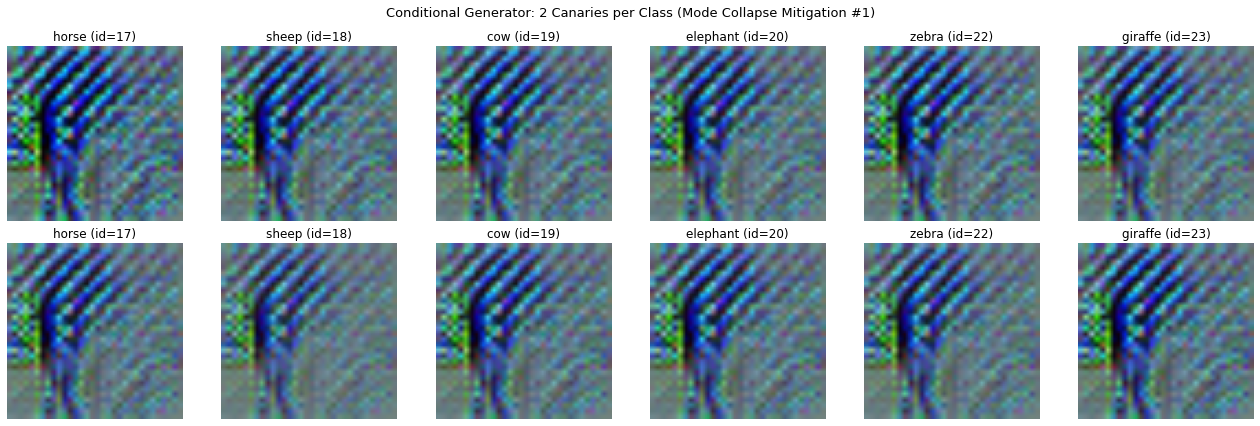

Mean pairwise L2 distance across 12 random samples: 4.12


In [9]:
import sys, os, shutil, glob, cv2, torch, random
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from types import SimpleNamespace
from tqdm import tqdm

sys.path.insert(0, os.path.abspath('..'))
from YOLOv8_Combiner import (
    add_defensivepatch_into_tensor, make_yolo_train_label,
    Yolov8Dataset, Canary, freeze_seed
)
from ObjectDetector.fjn_yolov8 import FJN_YOLOv8 as YOLOv8

# =============================================
#  FLAGS
# =============================================
retrain_from_scratch = False
EPOCHS = 50
BATCH_SIZE = 5
LR = 1e-3
WEIGHT = 2.0
SAVE_EVERY = 10
Z_DIM = 128

# COCO classes we condition on
CLASS_IDS = [17, 18, 19, 20, 22, 23]  # horse, sheep, cow, elephant, zebra, giraffe
CLASS_NAMES = ['horse', 'sheep', 'cow', 'elephant', 'zebra', 'giraffe']
NUM_CLASSES = len(CLASS_IDS)

# =============================================
#  PATHS
# =============================================
work_dir = './mode_collapse_exp/multiclass_generator'
ckpt_dir = os.path.join(work_dir, 'checkpoints')
final_ckpt = os.path.join(ckpt_dir, f'generator_epoch_{EPOCHS:03d}.pt')

# =============================================
#  ConditionalGenerativeCanary
# =============================================
class ConditionalGenerativeCanary(nn.Module):
    """Generator conditioned on [noise || bbox || class_onehot]."""
    def __init__(self, z_dim=128, bbox_dim=4, num_classes=6, canary_size=80):
        super().__init__()
        self.z_dim = z_dim
        self.num_classes = num_classes
        self.canary_size = canary_size
        input_dim = z_dim + bbox_dim + num_classes  # 138

        self.fc = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(256, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(512, 1024),
            nn.ReLU(inplace=True),
        )
        self.deconv = nn.Sequential(
            nn.ConvTranspose2d(16, 8, kernel_size=4, stride=2, padding=1),
            nn.ReLU(inplace=True),
            nn.ConvTranspose2d(8, 3, kernel_size=4, stride=2, padding=1),
            nn.Sigmoid(),
        )

    def forward(self, z):
        x = self.fc(z)
        x = x.view(-1, 16, 8, 8)
        x = self.deconv(x)
        x = F.interpolate(x, size=(self.canary_size, self.canary_size), mode='bilinear', align_corners=False)
        return x


# =============================================
#  Setup or load
# =============================================
if retrain_from_scratch and os.path.exists(work_dir):
    shutil.rmtree(work_dir)
    print(f"Cleared {work_dir}/")
os.makedirs(ckpt_dir, exist_ok=True)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

if os.path.exists(final_ckpt) and not retrain_from_scratch:
    print(f"Found final checkpoint at {final_ckpt} -- skipping training.")
    cond_generator = ConditionalGenerativeCanary(z_dim=Z_DIM, num_classes=NUM_CLASSES).to(device)
    ckpt = torch.load(final_ckpt, map_location=device)
    cond_generator.load_state_dict(ckpt['generator_state_dict'])
    cond_generator.eval()
    print(f"Loaded conditional generator (epoch {ckpt['epoch']})")
else:
    print("=== Approach 1: Multi-Class Conditional Generator ===")
    print(f"Device: {device}")
    freeze_seed(301)

    cfg = SimpleNamespace(
        canary_cls_id=22, canary_size=80,
        img_size=640, person_conf=0.05, overlap_thresh=0.4,
        defensive_patch_location='cc', eval_no_overlap=True,
        margin_size=0, faster=False,
    )

    print("Loading YOLOv8 detector...")
    detector = YOLOv8()
    for p in detector.model.parameters():
        p.requires_grad = False

    cond_generator = ConditionalGenerativeCanary(z_dim=Z_DIM, num_classes=NUM_CLASSES).to(device)
    print(f"Generator parameters: {sum(p.numel() for p in cond_generator.parameters()):,}")

    optimizer = optim.Adam(cond_generator.parameters(), lr=LR, amsgrad=True)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

    train_dataset = Yolov8Dataset(
        '../Data/traineval/VOC07_YOLOv8/train_120/benign',
        '../Data/traineval/VOC07_YOLOv8/train_120/adversarial',
        '../Data/traineval/VOC07_YOLOv8/train_120/benign_label',
        cfg.img_size
    )
    train_loader = torch.utils.data.DataLoader(
        train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0, drop_last=True
    )

    # Resume if checkpoints exist
    start_epoch = 1
    existing = sorted(glob.glob(os.path.join(ckpt_dir, 'generator_epoch_*.pt')))
    if existing and not retrain_from_scratch:
        latest = existing[-1]
        ckpt = torch.load(latest, map_location=device)
        cond_generator.load_state_dict(ckpt['generator_state_dict'])
        optimizer.load_state_dict(ckpt['optimizer_state_dict'])
        scheduler.load_state_dict(ckpt['scheduler_state_dict'])
        start_epoch = ckpt['epoch'] + 1
        print(f"Resumed from {latest}")

    print(f"\nTraining epochs {start_epoch} to {EPOCHS}")
    t = tqdm(total=EPOCHS - start_epoch + 1, ascii=True)
    for epoch in range(start_epoch, EPOCHS + 1):
        t.set_description(f'cond_gen epoch: {epoch}/{EPOCHS}')
        cond_generator.train()

        for i_batch, (benign_input, _, adv_input) in enumerate(train_loader):
            benign_input = benign_input.cuda()
            adv_input = adv_input.cuda()
            bs = benign_input.shape[0]

            # Sample per-image: noise, bbox, and class index
            eta = torch.randn(bs, Z_DIM, device=device)
            bbox = torch.rand(bs, 4, device=device)
            class_idx = torch.randint(0, NUM_CLASSES, (bs,), device=device)
            class_onehot = F.one_hot(class_idx, num_classes=NUM_CLASSES).float()
            z = torch.cat([eta, bbox, class_onehot], dim=1)  # (bs, 138)

            canary_patches = cond_generator(z)

            # Paste per-image, override cfg.canary_cls_id per iteration so labels
            # carry the sampled class
            adv_pos_all = []
            benign_pos_all = []

            detector.model.eval()
            for bi in range(bs):
                cfg.canary_cls_id = CLASS_IDS[class_idx[bi].item()]
                canary_bi = canary_patches[bi]
                _, adv_pos = add_defensivepatch_into_tensor(
                    detector, cfg, adv_input[bi:bi+1], canary_bi, random_palce=True
                )
                _, benign_pos = add_defensivepatch_into_tensor(
                    detector, cfg, benign_input[bi:bi+1], canary_bi, random_palce=True
                )
                adv_pos_all.extend(adv_pos)
                benign_pos_all.extend(benign_pos)

            adv_batch = make_yolo_train_label(adv_input, adv_pos_all)
            benign_batch = make_yolo_train_label(benign_input, benign_pos_all)

            detector.model.train()
            adv_loss, _ = detector.model.model(adv_batch)
            benign_loss, _ = detector.model.model(benign_batch)

            loss = WEIGHT * benign_loss - adv_loss

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            t.set_postfix({
                'b_loss': f'{benign_loss.item():.4f}',
                'a_loss': f'{adv_loss.item():.4f}',
            })

        scheduler.step()

        if epoch % SAVE_EVERY == 0 or epoch == EPOCHS:
            torch.save({
                'epoch': epoch,
                'generator_state_dict': cond_generator.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'scheduler_state_dict': scheduler.state_dict(),
            }, os.path.join(ckpt_dir, f'generator_epoch_{epoch:03d}.pt'))

        t.update(1)

    t.close()
    print("Training complete!")
    detector.model.eval()
    cond_generator.eval()

# =============================================
#  Visualize: one canary per class (6 classes)
# =============================================
print("\n=== Conditional Generator: Canaries Across Classes ===")
cond_generator.eval()

n_per_class = 2
fig, axes = plt.subplots(n_per_class, NUM_CLASSES, figsize=(3 * NUM_CLASSES, 3 * n_per_class))

for col, (cls_id, cls_name) in enumerate(zip(CLASS_IDS, CLASS_NAMES)):
    for row in range(n_per_class):
        eta = torch.randn(1, Z_DIM, device=device)
        bbox = torch.rand(1, 4, device=device)
        class_onehot = F.one_hot(torch.tensor([col], device=device), num_classes=NUM_CLASSES).float()
        z = torch.cat([eta, bbox, class_onehot], dim=1)
        with torch.no_grad():
            c = cond_generator(z)
        img = c[0].cpu().permute(1, 2, 0).numpy()
        ax = axes[row, col] if n_per_class > 1 else axes[col]
        ax.imshow(img)
        ax.set_title(f'{cls_name} (id={cls_id})')
        ax.axis('off')

fig.suptitle('Conditional Generator: 2 Canaries per Class (Mode Collapse Mitigation #1)', fontsize=13)
plt.tight_layout()
plt.show()

# Diversity metric
all_eta = torch.randn(12, Z_DIM, device=device)
all_bbox = torch.rand(12, 4, device=device)
all_classes = torch.randint(0, NUM_CLASSES, (12,), device=device)
all_onehot = F.one_hot(all_classes, num_classes=NUM_CLASSES).float()
all_z = torch.cat([all_eta, all_bbox, all_onehot], dim=1)
with torch.no_grad():
    all_canaries = cond_generator(all_z)
flat = all_canaries.view(12, -1)
dists = torch.cdist(flat, flat, p=2)
mask = torch.triu(torch.ones(12, 12, device=device), diagonal=1).bool()
print(f"Mean pairwise L2 distance across 12 random samples: {dists[mask].mean().item():.2f}")


### Approach 2: Aggressive Batch Diversity Loss

**Attempt to fight mode collapse by dramatically increasing the diversity loss weight and switching to cosine distance.**

Our previous diversity loss used L2 distance with weight 0.5. The problem is that the FFF detection loss has much larger magnitude, so the diversity term is effectively ignored.

**This attempt:**
- Bump diversity weight from 0.5 to **50.0** (100x increase)
- Switch from L2 to **cosine distance**: $\mathcal{L}_{div} = -\frac{1}{N(N-1)} \sum_{i \neq j} (1 - \cos(c_i, c_j))$
- Cosine distance is scale-invariant, so the generator can't "cheat" by making one canary very bright and another dark to boost L2 — it must produce **structurally** different patterns

This is the brute-force approach: if the diversity loss is loud enough, the generator has to produce different outputs.

=== Approach 2: Aggressive Diversity (weight=50.0, cosine) ===
Device: cuda
Loading YOLOv8 detector...


YOLOv8n summary (fused): 168 layers, 3151904 parameters, 0 gradients, 8.7 GFLOPs


Generator parameters: 693,387

Training epochs 1 to 50


aggressive_div epoch: 50/50: 100%|##########| 50/50 [04:13<00:00,  5.06s/it, b_loss=89.9169, a_loss=101.9201, cos_div=0.002]  


Training complete!

=== Aggressive Diversity Generator: 8 Samples ===


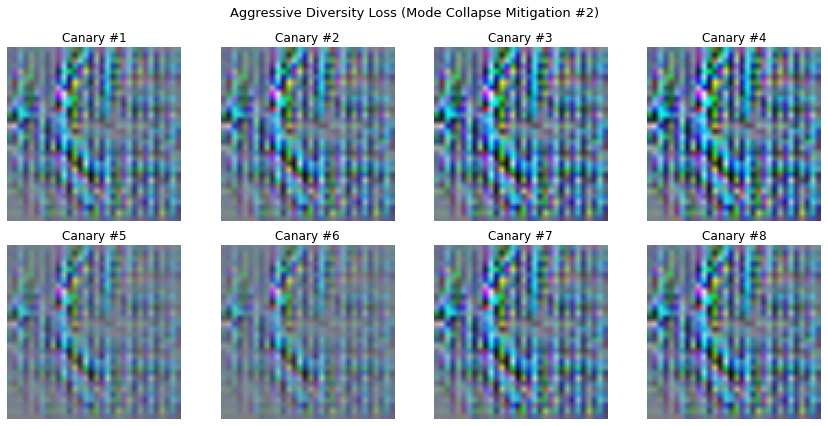

Mean pairwise L2 distance:    5.40
Mean pairwise cosine sim:     0.9957
Mean pairwise (1 - cos_sim):  0.0043


In [10]:
import sys, os, shutil, glob, cv2, torch
import torch.nn.functional as F
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from types import SimpleNamespace
from tqdm import tqdm

sys.path.insert(0, os.path.abspath('..'))
from YOLOv8_Combiner import (
    add_defensivepatch_into_tensor, make_yolo_train_label,
    Yolov8Dataset, Canary, freeze_seed
)
from ObjectDetector.fjn_yolov8 import FJN_YOLOv8 as YOLOv8

# =============================================
#  FLAGS
# =============================================
retrain_from_scratch = False
canary_cls_id = 22
EPOCHS = 50
BATCH_SIZE = 5
LR = 1e-3
WEIGHT = 2.0
SAVE_EVERY = 10
Z_DIM = 128
DIVERSITY_WEIGHT = 50.0  # 100x the previous value

work_dir = './mode_collapse_exp/aggressive_diversity'
ckpt_dir = os.path.join(work_dir, 'checkpoints')
final_ckpt = os.path.join(ckpt_dir, f'generator_epoch_{EPOCHS:03d}.pt')

if retrain_from_scratch and os.path.exists(work_dir):
    shutil.rmtree(work_dir)
    print(f"Cleared {work_dir}/")
os.makedirs(ckpt_dir, exist_ok=True)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

if os.path.exists(final_ckpt) and not retrain_from_scratch:
    print(f"Found checkpoint at {final_ckpt} -- skipping training.")
    gen_aggressive = GenerativeCanary(z_dim=Z_DIM).to(device)
    ckpt = torch.load(final_ckpt, map_location=device)
    gen_aggressive.load_state_dict(ckpt['generator_state_dict'])
    gen_aggressive.eval()
    print(f"Loaded generator (epoch {ckpt['epoch']})")
else:
    print(f"=== Approach 2: Aggressive Diversity (weight={DIVERSITY_WEIGHT}, cosine) ===")
    print(f"Device: {device}")
    freeze_seed(301)

    cfg = SimpleNamespace(
        canary_cls_id=canary_cls_id, canary_size=80,
        img_size=640, person_conf=0.05, overlap_thresh=0.4,
        defensive_patch_location='cc', eval_no_overlap=True,
        margin_size=0, faster=False,
    )

    print("Loading YOLOv8 detector...")
    detector = YOLOv8()
    for p in detector.model.parameters():
        p.requires_grad = False

    gen_aggressive = GenerativeCanary(z_dim=Z_DIM).to(device)
    print(f"Generator parameters: {sum(p.numel() for p in gen_aggressive.parameters()):,}")

    optimizer = optim.Adam(gen_aggressive.parameters(), lr=LR, amsgrad=True)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

    train_dataset = Yolov8Dataset(
        '../Data/traineval/VOC07_YOLOv8/train_120/benign',
        '../Data/traineval/VOC07_YOLOv8/train_120/adversarial',
        '../Data/traineval/VOC07_YOLOv8/train_120/benign_label',
        cfg.img_size
    )
    train_loader = torch.utils.data.DataLoader(
        train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0, drop_last=True
    )

    start_epoch = 1
    existing = sorted(glob.glob(os.path.join(ckpt_dir, 'generator_epoch_*.pt')))
    if existing and not retrain_from_scratch:
        latest = existing[-1]
        ckpt = torch.load(latest, map_location=device)
        gen_aggressive.load_state_dict(ckpt['generator_state_dict'])
        optimizer.load_state_dict(ckpt['optimizer_state_dict'])
        scheduler.load_state_dict(ckpt['scheduler_state_dict'])
        start_epoch = ckpt['epoch'] + 1
        print(f"Resumed from {latest}")

    print(f"\nTraining epochs {start_epoch} to {EPOCHS}")
    t = tqdm(total=EPOCHS - start_epoch + 1, ascii=True)
    for epoch in range(start_epoch, EPOCHS + 1):
        t.set_description(f'aggressive_div epoch: {epoch}/{EPOCHS}')
        gen_aggressive.train()

        for i_batch, (benign_input, _, adv_input) in enumerate(train_loader):
            benign_input = benign_input.cuda()
            adv_input = adv_input.cuda()
            bs = benign_input.shape[0]

            eta = torch.randn(bs, Z_DIM, device=device)
            bbox = torch.rand(bs, 4, device=device)
            z = torch.cat([eta, bbox], dim=1)

            canary_patches = gen_aggressive(z)

            adv_pos_all = []
            benign_pos_all = []
            detector.model.eval()
            for bi in range(bs):
                canary_bi = canary_patches[bi]
                _, adv_pos = add_defensivepatch_into_tensor(
                    detector, cfg, adv_input[bi:bi+1], canary_bi, random_palce=True
                )
                _, benign_pos = add_defensivepatch_into_tensor(
                    detector, cfg, benign_input[bi:bi+1], canary_bi, random_palce=True
                )
                adv_pos_all.extend(adv_pos)
                benign_pos_all.extend(benign_pos)

            adv_batch = make_yolo_train_label(adv_input, adv_pos_all)
            benign_batch = make_yolo_train_label(benign_input, benign_pos_all)

            detector.model.train()
            adv_loss, _ = detector.model.model(adv_batch)
            benign_loss, _ = detector.model.model(benign_batch)

            canary_loss = WEIGHT * benign_loss - adv_loss

            # Cosine diversity loss: maximize (1 - cos_sim) between batch pairs
            canaries_flat = canary_patches.view(bs, -1)
            canaries_norm = F.normalize(canaries_flat, p=2, dim=1)
            cos_sim = canaries_norm @ canaries_norm.t()  # (bs, bs)
            mask = torch.triu(torch.ones(bs, bs, device=device), diagonal=1).bool()
            # We want to MAXIMIZE (1 - cos_sim), so loss is negative of that
            diversity_loss = -(1 - cos_sim[mask]).mean()

            loss = canary_loss + DIVERSITY_WEIGHT * diversity_loss

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            t.set_postfix({
                'b_loss': f'{benign_loss.item():.4f}',
                'a_loss': f'{adv_loss.item():.4f}',
                'cos_div': f'{-diversity_loss.item():.3f}',
            })

        scheduler.step()

        if epoch % SAVE_EVERY == 0 or epoch == EPOCHS:
            torch.save({
                'epoch': epoch,
                'generator_state_dict': gen_aggressive.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'scheduler_state_dict': scheduler.state_dict(),
            }, os.path.join(ckpt_dir, f'generator_epoch_{epoch:03d}.pt'))

        t.update(1)

    t.close()
    print("Training complete!")
    detector.model.eval()
    gen_aggressive.eval()

# =============================================
#  Visualize 8 canaries + diversity metric
# =============================================
print("\n=== Aggressive Diversity Generator: 8 Samples ===")
gen_aggressive.eval()
n_show = 8
eta_s = torch.randn(n_show, Z_DIM, device=device)
bbox_s = torch.rand(n_show, 4, device=device)
z_s = torch.cat([eta_s, bbox_s], dim=1)
with torch.no_grad():
    canaries = gen_aggressive(z_s)

fig, axes = plt.subplots(2, 4, figsize=(12, 6))
for i, ax in enumerate(axes.flat):
    img = canaries[i].cpu().permute(1, 2, 0).numpy()
    ax.imshow(img)
    ax.set_title(f'Canary #{i+1}')
    ax.axis('off')
fig.suptitle('Aggressive Diversity Loss (Mode Collapse Mitigation #2)', fontsize=13)
plt.tight_layout()
plt.show()

# Metrics
flat = canaries.view(n_show, -1)
dists_l2 = torch.cdist(flat, flat, p=2)
norm = F.normalize(flat, p=2, dim=1)
cos_sim = norm @ norm.t()
mask = torch.triu(torch.ones(n_show, n_show, device=device), diagonal=1).bool()
print(f"Mean pairwise L2 distance:    {dists_l2[mask].mean().item():.2f}")
print(f"Mean pairwise cosine sim:     {cos_sim[mask].mean().item():.4f}")
print(f"Mean pairwise (1 - cos_sim):  {(1 - cos_sim[mask]).mean().item():.4f}")


### Approach 3: Generator Ensemble

**Attempt to fight mode collapse by training multiple independent generators instead of fighting collapse in one.**

Rather than forcing a single generator to produce diverse outputs, we train **N=5 small independent generators** with different random initialization seeds. Each generator will likely collapse to a *different* mode because of initialization variance.

At inference, we randomly pick one generator and sample a canary from it. The diversity now comes from the **pool of collapsed generators**, not from any single generator's noise input.

**Security argument still holds:** an adaptive attacker now faces 5 unknown collapsed generators instead of one. Even if each generator is mostly deterministic after training, the attacker doesn't know which generator produced the canary they see, so they can't target the specific pattern.

This is a pragmatic workaround — we sidestep mode collapse entirely rather than solving it.

YOLOv8n summary (fused): 168 layers, 3151904 parameters, 0 gradients, 8.7 GFLOPs


Device: cuda
Loading YOLOv8 detector...

---- Generator 1/5 (seed=301) ----


gen0 epoch 11/50:  20%|##        | 10/50 [00:50<03:17,  4.95s/it, b_loss=764.9358, a_loss=93.1746]

  Saved checkpoint: ./mode_collapse_exp/ensemble\checkpoints\gen_0_epoch_010.pt


gen0 epoch 21/50:  40%|####      | 20/50 [01:39<02:28,  4.95s/it, b_loss=136.3666, a_loss=99.3440]  

...

  Saved checkpoint: ./mode_collapse_exp/ensemble\checkpoints\gen_4_epoch_030.pt


gen4 epoch 41/50:  80%|########  | 40/50 [03:19<00:49,  5.00s/it, b_loss=229.7731, a_loss=94.2304]  

  Saved checkpoint: ./mode_collapse_exp/ensemble\checkpoints\gen_4_epoch_040.pt


gen4 epoch 50/50: 100%|##########| 50/50 [04:09<00:00,  4.99s/it, b_loss=264.1504, a_loss=85.7822]  


  Saved checkpoint: ./mode_collapse_exp/ensemble\checkpoints\gen_4_epoch_050.pt

=== Ensemble Ready: 5 generators ===

=== Ensemble Diversity: 2 Samples per Generator ===


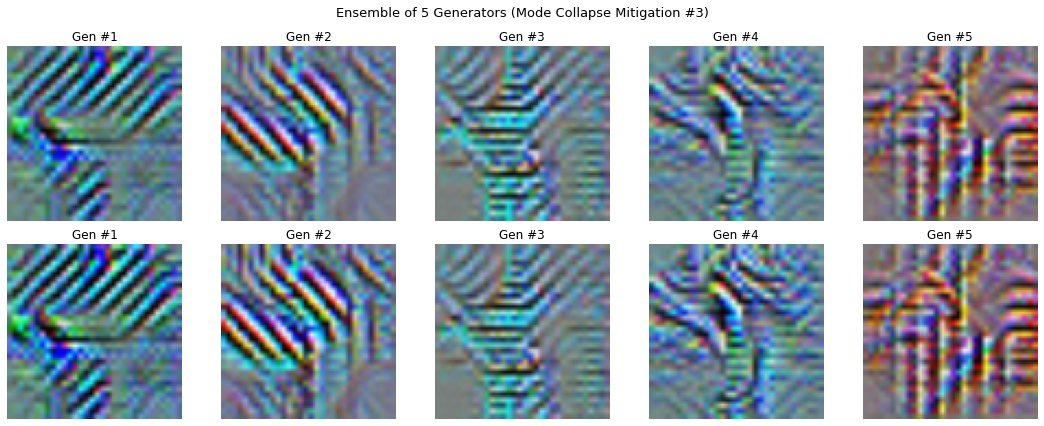

Mean pairwise L2 distance across ensemble (10 samples): 29.56


In [11]:
import sys, os, shutil, glob, cv2, torch, random
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from types import SimpleNamespace
from tqdm import tqdm

sys.path.insert(0, os.path.abspath('..'))
from YOLOv8_Combiner import (
    add_defensivepatch_into_tensor, make_yolo_train_label,
    Yolov8Dataset, Canary, freeze_seed
)
from ObjectDetector.fjn_yolov8 import FJN_YOLOv8 as YOLOv8

# =============================================
#  FLAGS
# =============================================
retrain_from_scratch = False
canary_cls_id = 22
EPOCHS = 50
BATCH_SIZE = 5
LR = 1e-3
WEIGHT = 2.0
SAVE_EVERY = 10
Z_DIM = 128
N_GENERATORS = 5
ENSEMBLE_SEEDS = [301, 302, 303, 304, 305]

work_dir = './mode_collapse_exp/ensemble'
ckpt_dir = os.path.join(work_dir, 'checkpoints')

if retrain_from_scratch and os.path.exists(work_dir):
    shutil.rmtree(work_dir)
    print(f"Cleared {work_dir}/")
os.makedirs(ckpt_dir, exist_ok=True)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

# Load detector once (shared across all generators)
print("Loading YOLOv8 detector...")
detector = YOLOv8()
for p in detector.model.parameters():
    p.requires_grad = False

cfg = SimpleNamespace(
    canary_cls_id=canary_cls_id, canary_size=80,
    img_size=640, person_conf=0.05, overlap_thresh=0.4,
    defensive_patch_location='cc', eval_no_overlap=True,
    margin_size=0, faster=False,
)

ensemble = []

for gen_idx in range(N_GENERATORS):
    seed = ENSEMBLE_SEEDS[gen_idx]
    final_ckpt_path = os.path.join(ckpt_dir, f'gen_{gen_idx}_epoch_{EPOCHS:03d}.pt')

    print(f"\n---- Generator {gen_idx+1}/{N_GENERATORS} (seed={seed}) ----")

    # --- Skip entirely if final ckpt exists ---
    if os.path.exists(final_ckpt_path) and not retrain_from_scratch:
        print(f"Found final checkpoint at {final_ckpt_path} -- loading.")
        g = GenerativeCanary(z_dim=Z_DIM).to(device)
        ckpt = torch.load(final_ckpt_path, map_location=device)
        g.load_state_dict(ckpt['generator_state_dict'])
        g.eval()
        ensemble.append(g)
        continue

    # --- Set up generator, optimizer, scheduler ---
    freeze_seed(seed)
    g = GenerativeCanary(z_dim=Z_DIM).to(device)
    optimizer = optim.Adam(g.parameters(), lr=LR, amsgrad=True)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

    # --- Resume from latest intermediate ckpt for this generator if available ---
    start_epoch = 1
    existing_this_gen = sorted(glob.glob(os.path.join(ckpt_dir, f'gen_{gen_idx}_epoch_*.pt')))
    if existing_this_gen and not retrain_from_scratch:
        latest = existing_this_gen[-1]
        ckpt = torch.load(latest, map_location=device)
        g.load_state_dict(ckpt['generator_state_dict'])
        if 'optimizer_state_dict' in ckpt:
            optimizer.load_state_dict(ckpt['optimizer_state_dict'])
        if 'scheduler_state_dict' in ckpt:
            scheduler.load_state_dict(ckpt['scheduler_state_dict'])
        start_epoch = ckpt['epoch'] + 1
        print(f"Resuming generator {gen_idx} from epoch {start_epoch} ({latest})")

    if start_epoch > EPOCHS:
        print(f"Generator {gen_idx} already at epoch {start_epoch-1}, skipping training.")
        g.eval()
        ensemble.append(g)
        continue

    # --- Train this generator ---
    train_dataset = Yolov8Dataset(
        '../Data/traineval/VOC07_YOLOv8/train_120/benign',
        '../Data/traineval/VOC07_YOLOv8/train_120/adversarial',
        '../Data/traineval/VOC07_YOLOv8/train_120/benign_label',
        cfg.img_size
    )
    train_loader = torch.utils.data.DataLoader(
        train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0, drop_last=True
    )

    t = tqdm(total=EPOCHS - start_epoch + 1, ascii=True)
    for epoch in range(start_epoch, EPOCHS + 1):
        t.set_description(f'gen{gen_idx} epoch {epoch}/{EPOCHS}')
        g.train()

        for i_batch, (benign_input, _, adv_input) in enumerate(train_loader):
            benign_input = benign_input.cuda()
            adv_input = adv_input.cuda()
            bs = benign_input.shape[0]

            eta = torch.randn(bs, Z_DIM, device=device)
            bbox = torch.rand(bs, 4, device=device)
            z = torch.cat([eta, bbox], dim=1)

            canary_patches = g(z)

            adv_pos_all = []
            benign_pos_all = []
            detector.model.eval()
            for bi in range(bs):
                canary_bi = canary_patches[bi]
                _, adv_pos = add_defensivepatch_into_tensor(
                    detector, cfg, adv_input[bi:bi+1], canary_bi, random_palce=True
                )
                _, benign_pos = add_defensivepatch_into_tensor(
                    detector, cfg, benign_input[bi:bi+1], canary_bi, random_palce=True
                )
                adv_pos_all.extend(adv_pos)
                benign_pos_all.extend(benign_pos)

            adv_batch = make_yolo_train_label(adv_input, adv_pos_all)
            benign_batch = make_yolo_train_label(benign_input, benign_pos_all)

            detector.model.train()
            adv_loss, _ = detector.model.model(adv_batch)
            benign_loss, _ = detector.model.model(benign_batch)

            loss = WEIGHT * benign_loss - adv_loss

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            t.set_postfix({
                'b_loss': f'{benign_loss.item():.4f}',
                'a_loss': f'{adv_loss.item():.4f}',
            })

        scheduler.step()

        # --- Save intermediate checkpoint every SAVE_EVERY epochs + final ---
        if epoch % SAVE_EVERY == 0 or epoch == EPOCHS:
            ckpt_path = os.path.join(ckpt_dir, f'gen_{gen_idx}_epoch_{epoch:03d}.pt')
            torch.save({
                'epoch': epoch,
                'generator_state_dict': g.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'scheduler_state_dict': scheduler.state_dict(),
                'seed': seed,
            }, ckpt_path)
            tqdm.write(f"  Saved checkpoint: {ckpt_path}")

        t.update(1)

    t.close()
    detector.model.eval()
    g.eval()
    ensemble.append(g)

print(f"\n=== Ensemble Ready: {len(ensemble)} generators ===")

# =============================================
#  Visualize 2 canaries from each generator (5x2 grid)
# =============================================
print("\n=== Ensemble Diversity: 2 Samples per Generator ===")
fig, axes = plt.subplots(2, N_GENERATORS, figsize=(3 * N_GENERATORS, 6))

all_samples = []
for col, g in enumerate(ensemble):
    g.eval()
    for row in range(2):
        eta = torch.randn(1, Z_DIM, device=device)
        bbox = torch.rand(1, 4, device=device)
        z = torch.cat([eta, bbox], dim=1)
        with torch.no_grad():
            c = g(z)
        all_samples.append(c[0])
        img = c[0].cpu().permute(1, 2, 0).numpy()
        axes[row, col].imshow(img)
        axes[row, col].set_title(f'Gen #{col+1}')
        axes[row, col].axis('off')

fig.suptitle('Ensemble of 5 Generators (Mode Collapse Mitigation #3)', fontsize=13)
plt.tight_layout()
plt.show()

# Inter-generator diversity metric
stacked = torch.stack(all_samples)  # (10, 3, 80, 80)
flat = stacked.view(10, -1)
dists = torch.cdist(flat, flat, p=2)
mask = torch.triu(torch.ones(10, 10, device=device), diagonal=1).bool()
print(f"Mean pairwise L2 distance across ensemble (10 samples): {dists[mask].mean().item():.2f}")

# Helper for inference: random pick from ensemble
def sample_from_ensemble(ensemble, z_dim, device):
    """Randomly pick a generator and sample one canary."""
    g = random.choice(ensemble)
    eta = torch.randn(1, z_dim, device=device)
    bbox = torch.rand(1, 4, device=device)
    z = torch.cat([eta, bbox], dim=1)
    with torch.no_grad():
        return g(z)


## Mode Collapse Mitigation: Results Summary

After running the three approaches above, we can compare them qualitatively (visual diversity of the canary grids) and quantitatively (mean pairwise L2 distance printed by each cell).

**What to look for:**
- **Approach 1 (Multi-Class Conditioning):** Canaries for different classes should look structurally different. If successful, the 6 classes will show visibly distinct patterns.
- **Approach 2 (Aggressive Diversity Loss):** The 8 samples should look more varied than cell-11. If the diversity weight was high enough, we may see colors and structures drift apart. Note: very high weight can damage detection F1.
- **Approach 3 (Ensemble):** Each generator in the 5-column grid should show its own distinct pattern, while samples within a single generator may still look similar (still collapsed individually). This validates the ensemble approach: diversity comes from *between* generators.

**Expected trade-off:** Approaches that increase diversity may reduce F1 or increase FPR on the full VOC07 evaluation. For the paper, report all three attempts honestly — what worked, what didn't, and what the trade-offs were. This is the standard scientific framing for an acknowledged limitation.